# **SLOT DIAGRAMS**

In [117]:
from IPython.display import Image, display

from diagrams import Diagram, Edge, Cluster
from diagrams.c4 import Person, Container, Database, System, SystemBoundary,  Relationship

from diagrams.onprem.network import Nginx


## **SYSTEM OVERVIEW**

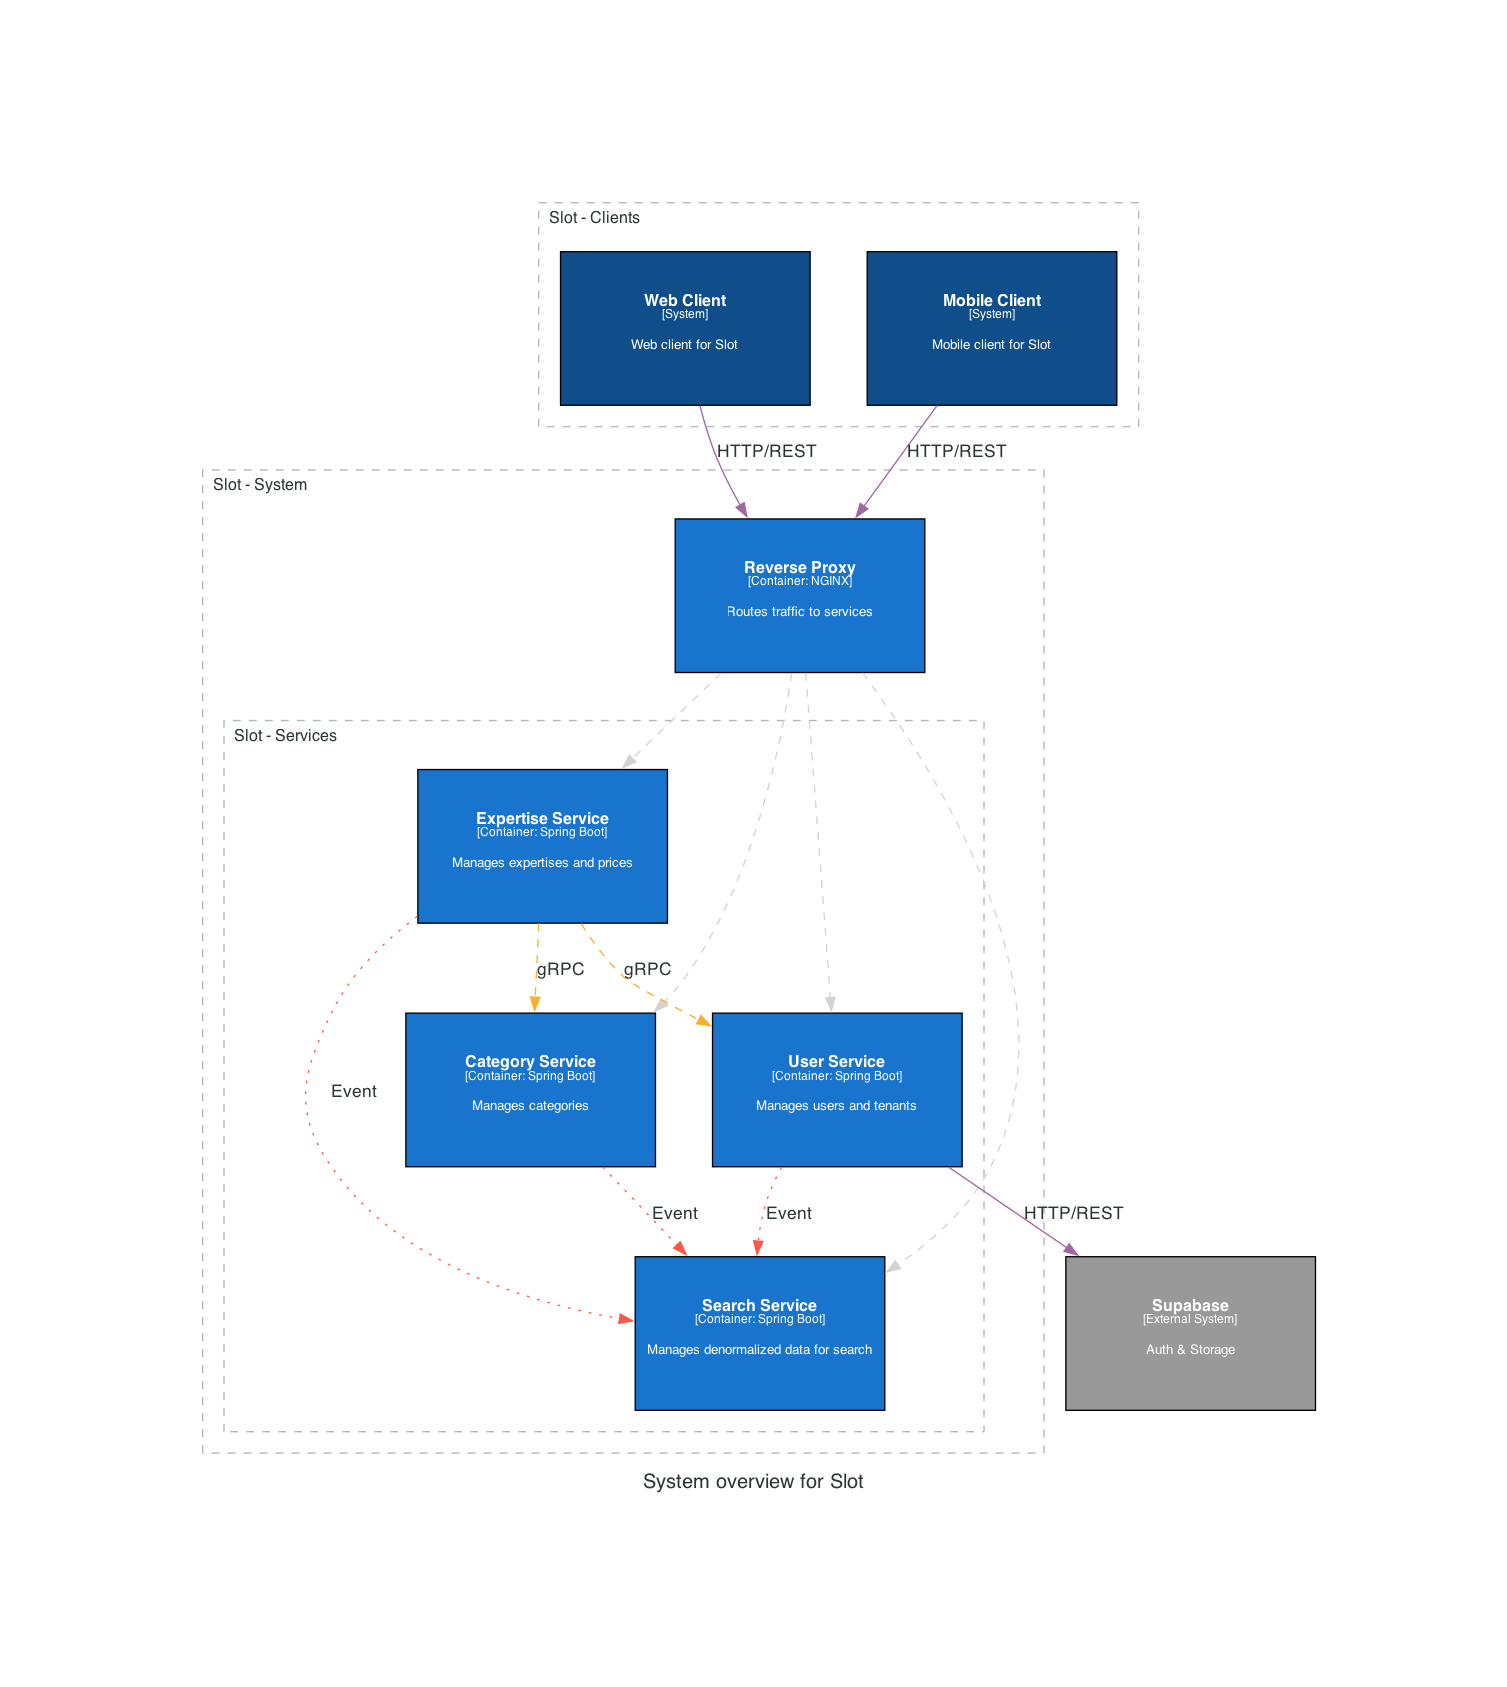

In [118]:
http  = Edge(label="HTTP/REST", color="#a265a1")
grpc  = Edge(label="gRPC", color="#f8af2c", style="dashed")
event = Edge(label="Event", color="#fd5847", style="dotted")
query = Edge(label="Query", color="#7684c8", style="dashed")

subtle = Edge(color="lightgray", style="dashed")

graph_attr = {
    "splines": "spline",
}

with Diagram("System overview for Slot", direction="TB", graph_attr=graph_attr, show=False):
    supabase = System(
        name="Supabase",
        description="Auth & Storage",
        external=True
    )

    with SystemBoundary("Slot - Clients"):
        client_web    = System(name="Web Client",    description="Web client for Slot")
        client_mobile = System(name="Mobile Client", description="Mobile client for Slot")

    with SystemBoundary("Slot - System"):
        reverse_proxy = Container(
            name="Reverse Proxy",
            technology="NGINX",
            description="Routes traffic to services"
        )

        with SystemBoundary("Slot - Services"):
            user_service = Container(
                name="User Service",
                technology="Spring Boot",
                description="Manages users and tenants",
            )
            category_service = Container(
                name="Category Service",
                technology="Spring Boot",
                description="Manages categories",
            )
            expertise_service = Container(
                name="Expertise Service",
                technology="Spring Boot",
                description="Manages expertises and prices",
            )
            search_service = Container(
                name="Search Service",
                technology="Spring Boot",
                description="Manages denormalized data for search",
            )

    [client_web, client_mobile] >> http >> reverse_proxy
    reverse_proxy >> subtle >> [user_service, category_service, expertise_service, search_service]

    user_service >> http >> supabase
    expertise_service >> grpc >> user_service
    expertise_service >> grpc >> category_service

    user_service >> event >> search_service
    category_service >> event >> search_service
    expertise_service >> event >> search_service



display(Image("system_overview_for_slot.png"))